In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm import tqdm

# Setup and Preprocessing

In [10]:
test_df = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
sample_sub=pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")

In [52]:
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
stems = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# Data Preparation & Stratified Split

In [9]:
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

In [50]:
train_df.head()

,path,genre
67,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,classical
199,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,disco
387,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,pop
394,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,pop
373,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,pop


# Milestone 2

**What is the mean duration (in seconds) of the Jazz genre stems in train dataset?**

In [53]:
jazz_songs = train_df[train_df['genre'] == 'jazz']

durations = []
for p in jazz_songs['path']:
    for s in stems:
        durations.append(librosa.get_duration(filename=os.path.join(p, s)))

print(sum(durations) / len(durations))

/tmp/ipykernel_55/1082496385.py:6: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  durations.append(librosa.get_duration(filename=os.path.join(p, s)))


30.025229024943307


**What are the unique sample rates present in the dataset?**

In [55]:
sample_rates = set()

for p in train_df['path']:
    for s in stems:
        file_path = os.path.join(p, s)
        try:
            _, sr = librosa.load(file_path, sr=None, duration=0.05)
            sample_rates.add(sr)
        except:
            pass

print(sorted(sample_rates))

[44100]


**How many corrupted or zero-byte audio files are present in the train dataset?**

In [56]:
bad = 0
for p in train_df['path']:
    for stem in stems:
        file_path = os.path.join(p, stem)
        try:
            if os.path.getsize(file_path) == 0:
                bad += 1
            else:
                librosa.load(file_path, sr=None, duration=0.01)
        except:
            bad += 1

print(bad)

0


**What is the average peak amplitude (in dB) for vocal stems in train dataset?**

In [57]:
peak_dbs = []

for p in train_df['path']:
    vocal_file = os.path.join(p, "vocals.wav")
    try:
        y, _ = librosa.load(vocal_file, sr=None, mono=True)
        peak = np.max(np.abs(y))
        if peak > 0:
            peak_dbs.append(20 * np.log10(peak))
    except:
        pass

print(sum(peak_dbs) / len(peak_dbs))

-12.810578


**What is the mean spectral centroid for 'blues' genre in the train dataset?**

In [58]:
blues = train_df[train_df['genre'] == 'blues']
centroids = []

for p in blues['path']:
    file_path = os.path.join(p, "other.wav")
    try:
        y, sr = librosa.load(file_path, sr=None)
        cent = librosa.feature.spectral_centroid(y=y, sr=sr)
        centroids.append(np.mean(cent))
    except:
        pass

print(sum(centroids) / len(centroids))

1426.029321739546


**Which genre in the train dataset has the highest mean spectral centroid?**

In [59]:
results = {}

for genre in train_df['genre'].unique():
    centroids = []
    subset = train_df[train_df['genre'] == genre]
    for p in subset['path']:
        file_path = os.path.join(p, "other.wav")
        try:
            y, sr = librosa.load(file_path, sr=None)
            cent = librosa.feature.spectral_centroid(y=y, sr=sr)
            centroids.append(np.mean(cent))
        except:
            pass
    if centroids:
        results[genre] = sum(centroids) / len(centroids)

print(max(results, key=results.get))

hiphop


**How many stem audio files in the train dataset contain silence in the first 0.5 seconds?**

In [60]:
silent = 0

for p in train_df['path']:
    for s in stems:
        file_path = os.path.join(p, s)
        try:
            y, sr = librosa.load(file_path, sr=None)
            if np.max(np.abs(y[:int(0.5 * sr)])) < 0.01:
                silent += 1
        except:
            pass

print(silent)

315


**Model Training Code**

/tmp/ipykernel_55/2189213165.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues     0.2000    0.1000    0.1333        10
   classical     0.1429    0.1000    0.1176        10
     country     0.1000    0.1000    0.1000        10
       disco     0.2000    0.4000    0.2667        10
      hiphop     0.2500    0.1000    0.1429        10
        jazz     0.0000    0.0000    0.0000        10
       metal     0.4091    0.9000    0.5625        10
         pop     0.2000    0.2000    0.2000        10
      reggae     0.0000    0.0000    0.0000        10
        rock     0.0000    0.0000    0.0000        10

    accuracy                         0.1900       100
   macro avg     0.1502    0.1900    0.1523       100
weighted avg     0.1502    0.1900    0.1523       100



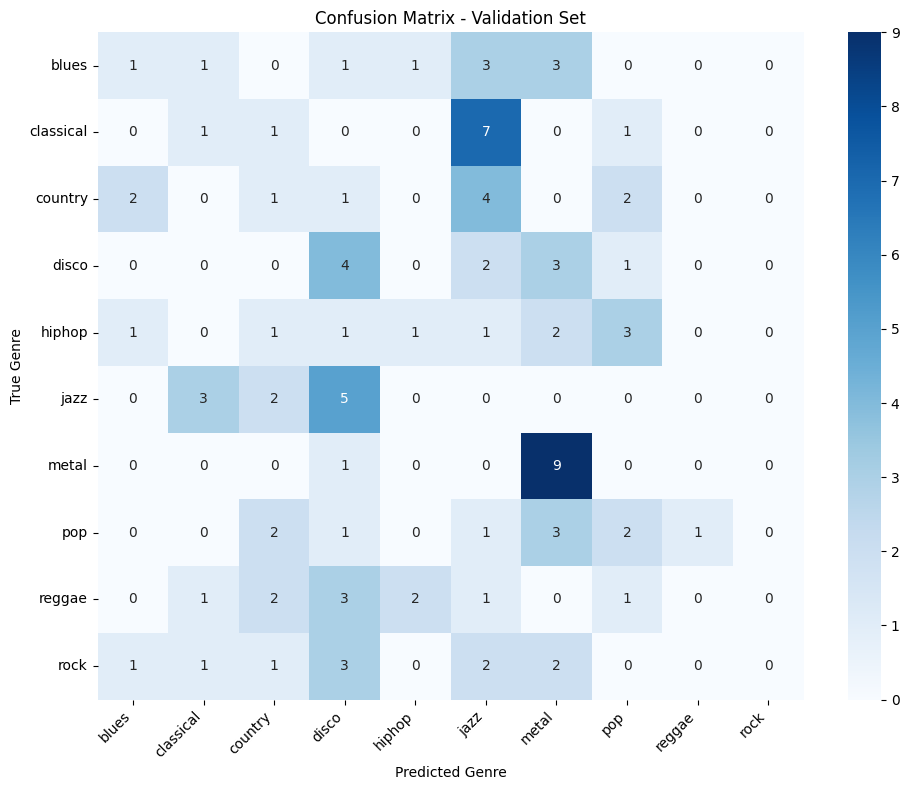

In [38]:
# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 1. Make predictions on validation set
y_pred = clf.predict(X_val)

# 2. Compute macro F1 score
macro_f1 = f1_score(y_val, y_pred, average='macro')

# 3. Compute confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=clf.classes_)

# 4. Compute classification report
cr = classification_report(y_val, y_pred, target_names=clf.classes_, digits=4)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

# 5. Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.title('Confusion Matrix - Validation Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Submission Trial

In [61]:
tp = np.diag(cm)
fn = cm.sum(axis=1) - tp

best_tp_class = clf.classes_[np.argmax(tp)]
lowest_fn_class = clf.classes_[np.argmin(fn)]

print(best_tp_class)
print(lowest_fn_class)

metal
metal
